In [2]:
# Download preprocessed AES_HD from GitHub (small zip file)
!wget https://github.com/gabzai/Methodology-for-efficient-CNN-architectures-in-SCA/raw/master/AES_HD/AES_HD_dataset.zip

# Unzip
!unzip AES_HD_dataset.zip

# Check what's inside
!ls -lh

--2026-06-11 16:58:33--  https://github.com/gabzai/Methodology-for-efficient-CNN-architectures-in-SCA/raw/master/AES_HD/AES_HD_dataset.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gabzai/Methodology-for-efficient-CNN-architectures-in-SCA/master/AES_HD/AES_HD_dataset.zip [following]
--2026-06-11 16:58:33--  https://raw.githubusercontent.com/gabzai/Methodology-for-efficient-CNN-architectures-in-SCA/master/AES_HD/AES_HD_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86203943 (82M) [application/zip]
Saving to: ‘AES_HD_dataset.zip’

AES_HD_dataset.zip  100%[===================

New X_train shape: (50000, 1250, 1)

Training Regularized CNN (No Class Weights)...
Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.1562 - loss: 2.4564 - val_accuracy: 0.2175 - val_loss: 1.9572 - learning_rate: 0.0010
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.2309 - loss: 1.9662 - val_accuracy: 0.2618 - val_loss: 1.7952 - learning_rate: 0.0010
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2507 - loss: 1.8306 - val_accuracy: 0.2649 - val_loss: 1.7751 - learning_rate: 0.0010
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.2653 - loss: 1.7937 - val_accuracy: 0.2658 - val_loss: 1.7679 - learning_rate: 0.0010
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2706 - loss: 1.7791 - val_accuracy: 0.2659 - val_loss: 1.7673 - learning_rate: 0.0010
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.2707 - loss: 1.7754 - val_accuracy: 0.2659 - val_loss: 1.7688 - learning_rate

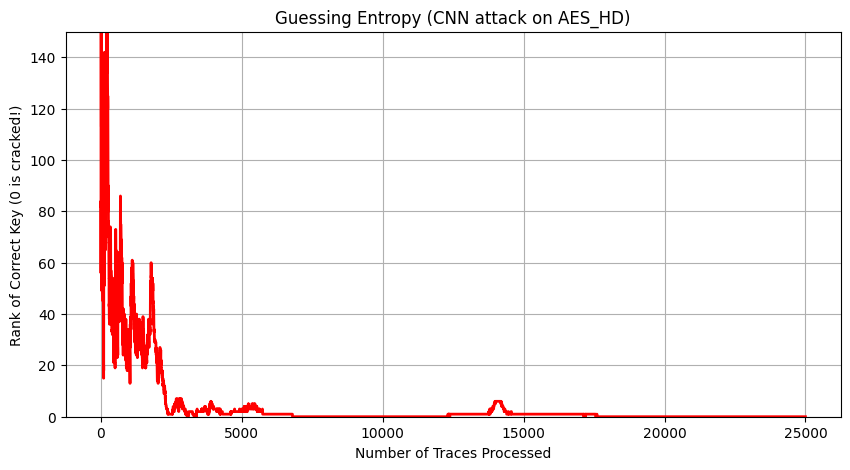


Final Rank of the correct key after 25000 traces: 0
SUCCESS: The AES Key was successfully cracked! 🎉


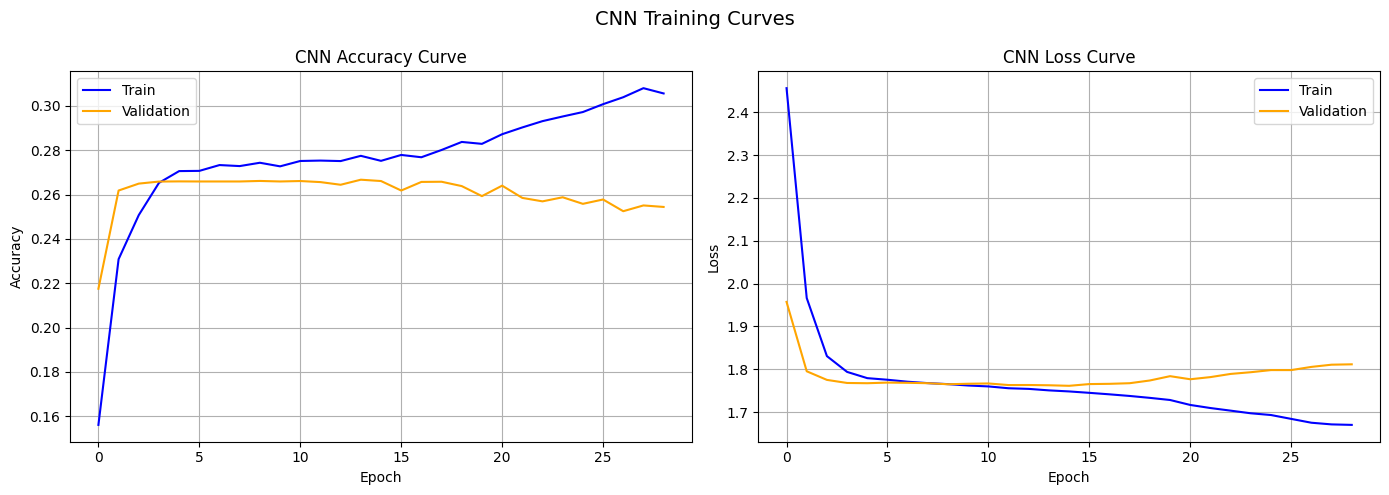

In [3]:
# CNN on AES_HD
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


X_train = np.load('/content/AES_HD_dataset/profiling_traces_AES_HD.npy')
Y_train = np.load('/content/AES_HD_dataset/profiling_labels_AES_HD.npy')
X_test  = np.load('/content/AES_HD_dataset/attack_traces_AES_HD.npy')
Y_test  = np.load('/content/AES_HD_dataset/attack_labels_AES_HD.npy')


Y_train = Y_train.flatten().astype(int)
Y_test  = Y_test.flatten().astype(int)
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')


hw = np.vectorize(lambda x: bin(int(x)).count('1'))
Y_train_hw = hw(Y_train)
Y_test_hw  = hw(Y_test)


scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Y_train_cat = to_categorical(Y_train_hw, num_classes=9)
Y_test_cat  = to_categorical(Y_test_hw,  num_classes=9)


weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_hw),
    y=Y_train_hw
)
class_weights_dict = {i: weights[i] for i in range(len(weights))}


X_train_cnn = X_train[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]
print(f"New X_train shape: {X_train_cnn.shape}")


cnn_model = Sequential([
    Input(shape=(1250, 1)),

    Conv1D(filters=8, kernel_size=11, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4, strides=4),

    Conv1D(filters=16, kernel_size=11, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4, strides=4),

    Conv1D(filters=32, kernel_size=11, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4, strides=4),

    Flatten(),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(9, activation='softmax')
])


cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining Regularized CNN (No Class Weights)...")
h_cnn = cnn_model.fit(
    X_train_cnn, Y_train_cat,
    epochs=100,
    batch_size=256,
    validation_data=(X_test_cnn, Y_test_cat),
    callbacks=[early_stop, reduce_lr],
    verbose=1

)




C_test = np.load('/content/AES_HD_dataset/attack_ciphertext_AES_HD.npy')

Sbox_inv = np.array([
    0x52, 0x09, 0x6a, 0xd5, 0x30, 0x36, 0xa5, 0x38, 0xbf, 0x40, 0xa3, 0x9e, 0x81, 0xf3, 0xd7, 0xfb,
    0x7c, 0xe3, 0x39, 0x82, 0x9b, 0x2f, 0xff, 0x87, 0x34, 0x8e, 0x43, 0x44, 0xc4, 0xde, 0xe9, 0xcb,
    0x54, 0x7b, 0x94, 0x32, 0xa6, 0xc2, 0x23, 0x3d, 0xee, 0x4c, 0x95, 0x0b, 0x42, 0xfa, 0xc3, 0x4e,
    0x08, 0x2e, 0xa1, 0x66, 0x28, 0xd9, 0x24, 0xb2, 0x76, 0x5b, 0xa2, 0x49, 0x6d, 0x8b, 0xd1, 0x25,
    0x72, 0xf8, 0xf6, 0x64, 0x86, 0x68, 0x98, 0x16, 0xd4, 0xa4, 0x5c, 0xcc, 0x5d, 0x65, 0xb6, 0x92,
    0x6c, 0x70, 0x48, 0x50, 0xfd, 0xed, 0xb9, 0xda, 0x5e, 0x15, 0x46, 0x57, 0xa7, 0x8d, 0x9d, 0x84,
    0x90, 0xd8, 0xab, 0x00, 0x8c, 0xbc, 0xd3, 0x0a, 0xf7, 0xe4, 0x58, 0x05, 0xb8, 0xb3, 0x45, 0x06,
    0xd0, 0x2c, 0x1e, 0x8f, 0xca, 0x3f, 0x0f, 0x02, 0xc1, 0xaf, 0xbd, 0x03, 0x01, 0x13, 0x8a, 0x6b,
    0x3a, 0x91, 0x11, 0x41, 0x4f, 0x67, 0xdc, 0xea, 0x97, 0xf2, 0xcf, 0xce, 0xf0, 0xb4, 0xe6, 0x73,
    0x96, 0xac, 0x74, 0x22, 0xe7, 0xad, 0x35, 0x85, 0xe2, 0xf9, 0x37, 0xe8, 0x1c, 0x75, 0xdf, 0x6e,
    0x47, 0xf1, 0x1a, 0x71, 0x1d, 0x29, 0xc5, 0x89, 0x6f, 0xb7, 0x62, 0x0e, 0xaa, 0x18, 0xbe, 0x1b,
    0xfc, 0x56, 0x3e, 0x4b, 0xc6, 0xd2, 0x79, 0x20, 0x9a, 0xdb, 0xc0, 0xfe, 0x78, 0xcd, 0x5a, 0xf4,
    0x1f, 0xdd, 0xa8, 0x33, 0x88, 0x07, 0xc7, 0x31, 0xb1, 0x12, 0x10, 0x59, 0x27, 0x80, 0xec, 0x5f,
    0x60, 0x51, 0x7f, 0xa9, 0x19, 0xb5, 0x4a, 0x0d, 0x2d, 0xe5, 0x7a, 0x9f, 0x93, 0xc9, 0x9c, 0xef,
    0xa0, 0xe0, 0x3b, 0x4d, 0xae, 0x2a, 0xf5, 0xb0, 0xc8, 0xeb, 0xbb, 0x3c, 0x83, 0x53, 0x99, 0x61,
    0x17, 0x2b, 0x04, 0x7e, 0xba, 0x77, 0xd6, 0x26, 0xe1, 0x69, 0x14, 0x63, 0x55, 0x21, 0x0c, 0x7d
])

hw_lookup = np.array([bin(x).count('1') for x in range(256)])


print("\nPredicting probabilities using CNN...")
predictions = cnn_model.predict(X_test_cnn)


num_traces_to_use = len(C_test)
key_probabilities = np.zeros(256)
guessing_entropy = []
CORRECT_KEY = 0x00

print(f"Running Attack over {num_traces_to_use} traces...")

for t in range(num_traces_to_use):
    c_11 = int(C_test[t][11])
    c_7  = int(C_test[t][7])

    for k_guess in range(256):
        hypothetical_leakage = Sbox_inv[c_11 ^ k_guess] ^ c_7
        hypothetical_hw = hw_lookup[hypothetical_leakage]

        prob = predictions[t][hypothetical_hw]
        prob = max(prob, 1e-20)
        key_probabilities[k_guess] += np.log(prob)

    ranked_keys = np.argsort(key_probabilities)[::-1]
    rank = list(ranked_keys).index(CORRECT_KEY)
    guessing_entropy.append(rank)


plt.figure(figsize=(10, 5))
plt.plot(guessing_entropy, color='red', linewidth=2)
plt.title("Guessing Entropy (CNN attack on AES_HD)")
plt.xlabel("Number of Traces Processed")
plt.ylabel("Rank of Correct Key (0 is cracked!)")
plt.ylim(0, 150)
plt.grid(True)
plt.show()

print(f"\nFinal Rank of the correct key after {num_traces_to_use} traces: {guessing_entropy[-1]}")
if guessing_entropy[-1] == 0:
    print("SUCCESS: The AES Key was successfully cracked! 🎉")
else:
    print("ATTACK FAILED: The correct key was not ranked #1.")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training Curves', fontsize=14)

axes[0].plot(h_cnn.history['accuracy'],     label='Train', color='blue')
axes[0].plot(h_cnn.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('CNN Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(h_cnn.history['loss'],     label='Train', color='blue')
axes[1].plot(h_cnn.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('CNN Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()